In [1]:
class Value:

    # will store data and it's gradient along with operations like +,*,etc
    # _ defines private - don't use it outside
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0

        #private
        self._backward = lambda: None   #default fallback for lead node; does nothing
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out


    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data*other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out


    def __pow__(self,other):
        assert isinstance(other, (int,float))
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out


    def relu(self):
        out = Value(0 if self.data<0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out


    # def __tanh__(self):

    # sorting topologically. initially we go from left to right however, backprop needs us to go reversed from right to left hence 
    # 'reversed' is used at the end

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v._prev:
                    build_topo(child)

                topo.append(v)
        build_topo(self)

        self.grad=1
        for v in reversed(topo):
            v._backward()


    # simple functions for cases like 2+a, 2*a etc hence radd, rmul respectively; ctrl+c, ctrl+v
    def __neg__(self):                                  
        return self * -1 

    def __radd__(self,  other):
        return self + other
                                 
    def __sub__(self, other): 
        return self + (-other)

    def __rsub__(self, other): 
        return other + (-self)

    def __rmul__(self, other): 
        return self * other
                                 
    def __truediv__(self, other): 
        return self * other**-1

    def __rtruediv__(self, other): 
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
                

    
         

In [2]:
import math
import random

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return[]


class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        # He initilization for some fun
        he_std = math.sqrt(2/nin)
        self.w = [Value(random.gauss(0,he_std)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b] #wrapping self.b to make it a list. or else it was a value object

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"
        


class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self,x):
         out = [n(x) for n in self.neurons]
         return out[0] if len(out) == 1 else out


    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [3]:
#demo copy
# Karpathy copy paste from demo.ipynb - for testing purpose purely
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Karpathy copy paste from demo.ipynb - for testing purpose purely
np.random.seed(1337)
random.seed(1337)

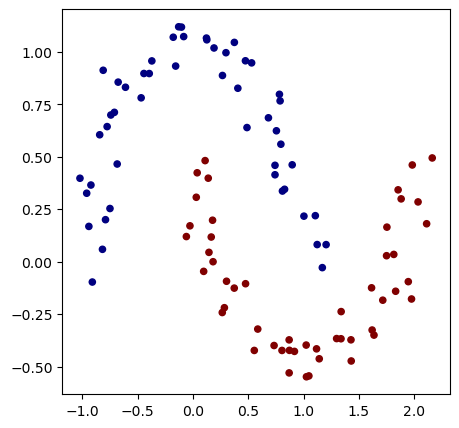

In [5]:
# Karpathy copy paste from demo.ipynb - for testing purpose purely
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [6]:
# Karpathy copy paste from demo.ipynb - for testing purpose purely
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [7]:
# Karpathy copy paste from demo.ipynb - for testing purpose purely
def loss(batch_size=None):
    
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # forward the model to get scores
    scores = list(map(model, inputs))
    
    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=0.9672680277810358, grad=0) 0.63


In [8]:
# Karpathy copy paste from demo.ipynb - for testing purpose purely
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 0.9672680277810358, accuracy 63.0%
step 1 loss 0.5176194526066102, accuracy 81.0%
step 2 loss 0.9003163166600445, accuracy 75.0%
step 3 loss 0.42745369728689253, accuracy 82.0%
step 4 loss 0.5395463446117528, accuracy 80.0%
step 5 loss 0.2847687748260586, accuracy 88.0%
step 6 loss 0.2690235515306326, accuracy 89.0%
step 7 loss 0.260016098445327, accuracy 91.0%
step 8 loss 0.2655348811487876, accuracy 88.0%
step 9 loss 0.2771019243621258, accuracy 90.0%
step 10 loss 0.3107037310745716, accuracy 85.0%
step 11 loss 0.3096498949153159, accuracy 91.0%
step 12 loss 0.28423475486303396, accuracy 87.0%
step 13 loss 0.2881135324077512, accuracy 92.0%
step 14 loss 0.23523881666678648, accuracy 89.0%
step 15 loss 0.22882714465410942, accuracy 94.0%
step 16 loss 0.21513166117438748, accuracy 90.0%
step 17 loss 0.2018431331920074, accuracy 94.0%
step 18 loss 0.1946914558011302, accuracy 92.0%
step 19 loss 0.18828033109484146, accuracy 95.0%
step 20 loss 0.1920610888780227, accuracy 93.

(-1.548639298268643, 1.951360701731357)

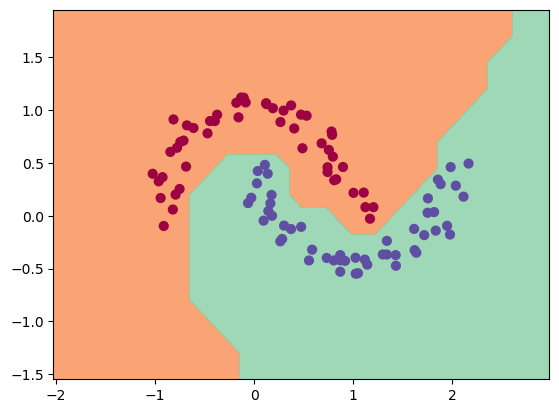

In [9]:
# Karpathy copy paste from demo.ipynb - for testing purpose purely
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())